In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
import cv2

In [2]:
## CV2 MAINLY HELPS TO READ AN IMAGE
## pd.imread

In [3]:
## HERE IN OPEN CV FOLDER WE HAVE HARR CASCADES
## THESE MAINLY HELPS US TO DETECT DIFFERENT FEATURES FROM THE FACE - EX. EYE,LEFT_EYE,RIGHT_EYE

In [7]:
## SAMPLE CODE TO SEE HOW OPENCV WORKS AND HELPS TO READ AN IMAGE
image_ = cv2.imread('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/test_images/sharapova1.jpg')



In [9]:
## HERE WE CAN SEE THE SHAPE HAS THREE DIMENSIONS
## ONE IS --> X
## OTHER IS --> Y
## THIRD IS --> RGB VALUES [WHICH REPRESENTS COLOUR]


image_.shape

(555, 700, 3)

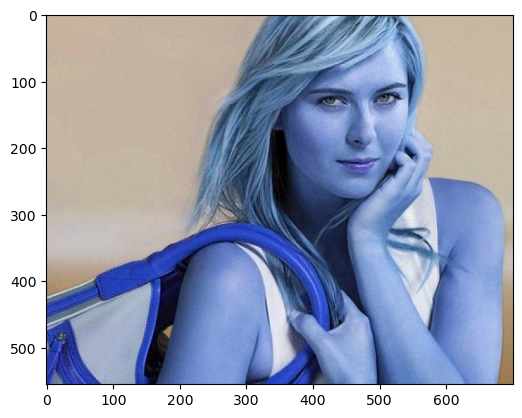

In [11]:
## TO VIEW THE IMAGES WE USE PLT -> WHICH HAS METHOD CALLED [.imshow]

plt.imshow(image_)

In [13]:
## HERE WE CAN CLEARLY OBSERVE ,THAT THE IMAGE SHOWN IS IN COLORED FORMAT
## HOW TO CHANGE THE COLOUR?

gray = cv2.cvtColor(image_ , cv2.COLOR_BGR2GRAY)
gray.shape

(555, 700)

In [15]:
## WE CAN SEE GRAY VALUES HOWEVER VALUES WILL BE BETWEEN 0-256 RGB VALUES

gray

array([[175, 175, 175, ..., 176, 175, 174],
       [175, 175, 175, ..., 177, 175, 174],
       [175, 175, 175, ..., 177, 176, 174],
       ...,
       [ 84,  87,  88, ..., 113, 113, 113],
       [ 88,  89,  90, ..., 113, 113, 113],
       [ 93,  91,  91, ..., 112, 112, 112]], dtype=uint8)

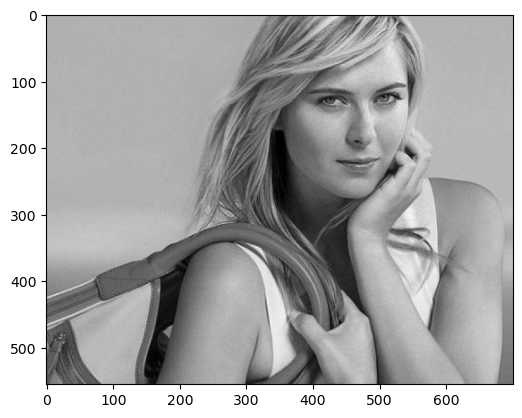

In [17]:
plt.imshow(gray , cmap = 'gray')

In [19]:
## HERE WE USE HAAR CASCADES METHOD TO DETECT DIFFERENT FEATURES ON FACES
## WE SELECT MULTIPLE CRITERIA IN FACE TO BUILD A BETTER MODEL

## WE USE MULTIPLE MASKS TO DETECT FACE AREAS

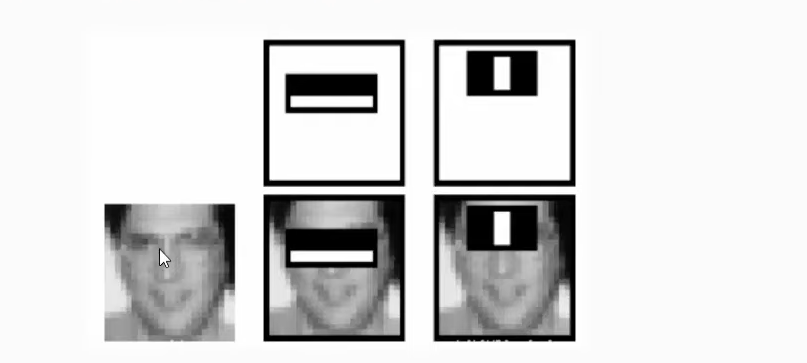

In [22]:
## FIRSTLY WE HAVE TO LOAD THE REQUIRED XML CLASSIFIERS
## THEN LOAD OUR INPUT IMAGE IN GRAYSCALE MODE

face_cascade = cv2.CascadeClassifier('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/opencv/haarcascades/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

## HERE WE CAN SEE OUTPUTS IN THE FORM OF ARRAY
## IF WE HAD TWO FACES WE WOULD HAVE GOT TWO ARRAYS
## [X -AXIS,Y-AXIS,WIDTH,HEIGHT]

array([[352,  38, 233, 233]], dtype=int32)

In [24]:
## AS IT'S 2D ARRAY FORMAT WE CAN STORE IT FORMAT
(x,y,w,h) = faces[0]
x,y,w,h

(352, 38, 233, 233)

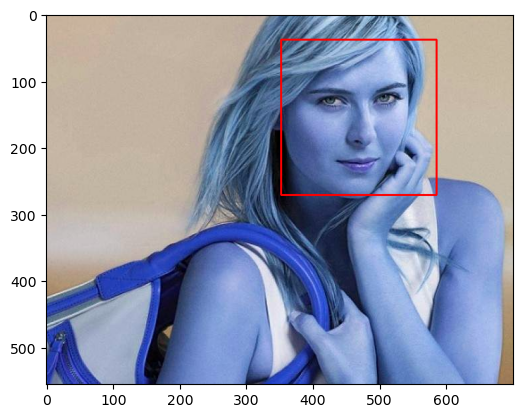

In [26]:
## WE USE THOSE FORMATTED VALUES TO DRAW A RECTANGLE AROUND THE FACES
## WHICH HELPS TO CROP THE IMAGE
## WHERE WE DRAW A RECTANGLE WITH IMAGE AND THE RGB COLUR ,WITH FORMATTED VALUES OF FACE [X,Y,W,H]

face_image = cv2.rectangle(image_,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_image)

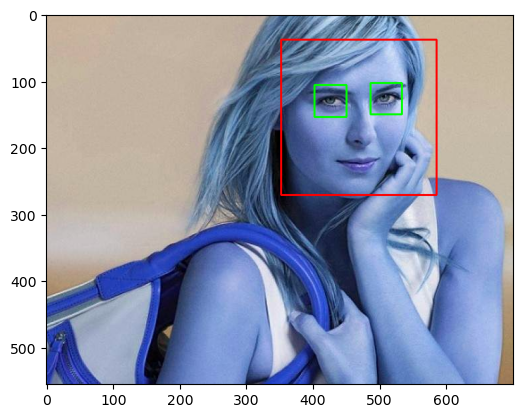

In [28]:
## NOW WE CODE TO  DETECT TWO EYES BY USING HARR CASACDES
## BY CREATING A FUNCTION FOR BOTH FACES AND EYES
## WE CAN HAVE MULTIPLE FACES OR EYES
## HERE IN THIS CODE ROI_COLOR REFERS TO RECTANGULAR FACE PART

cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_image = cv2.rectangle(image_,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h,x:x+w]
    roi_color = face_image[y:(y*4)+h,x:(x*2)+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.figure()
plt.imshow(face_image, cmap = 'gray')
plt.show()


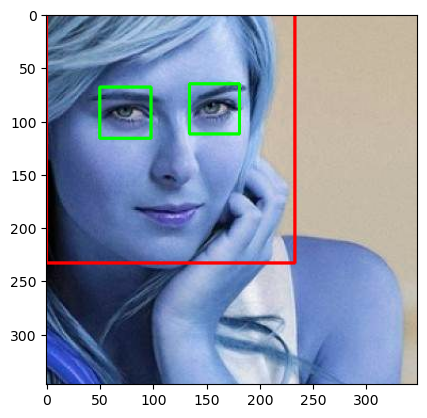

In [30]:
## AS WE ARE INTRESTED IN FACIAL REGION OF EVERY DATASET WE USE THIS METHOD

%matplotlib inline
plt.imshow(roi_color,cmap = 'gray')

In [32]:
## NOW WE ARE DEFINING THE FUNCTION WHICH MAINLY SERVES AS
## WHEN WE INPUT AN IMAGE --> FUNCTION RETURNS US THE CROPPED FACE DIRECTLY IF THE FACE AND TWO EYES ARE DETECTED
## WHICH WE CAN RUN ON ALL OUR IMAGES TOGETHER [AS UNTIL NOW WE HAVE DONE FOR A SINGLE FACE]


def get_cropped_image_if_2_eyes(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    euqalized = cv2.equalizeHist(gray)
    face = face_cascade.detectMultiScale(gray,1.05,5)
    for (x,y,w,h) in faces:
        roi_gray  = gray[y:(y*2)+h , x:(x*2)+w]
        roi_color = gray[y:(y*4)+h , x:(x*2)+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color
            

In [34]:
## NOW LET'S PASS THE ORIGINAL IMAGE PATH AND CHECK OUT FOR RESULTS

cropped_image = get_cropped_image_if_2_eyes('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/test_images/sharapova1.jpg')


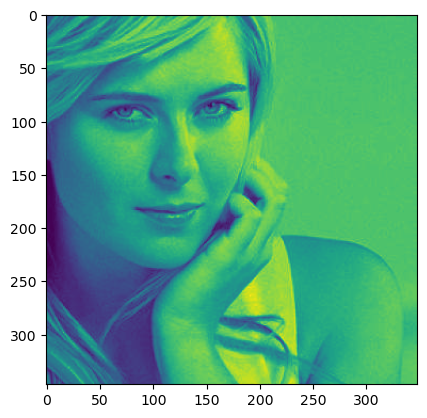

In [36]:
plt.imshow(cropped_image)

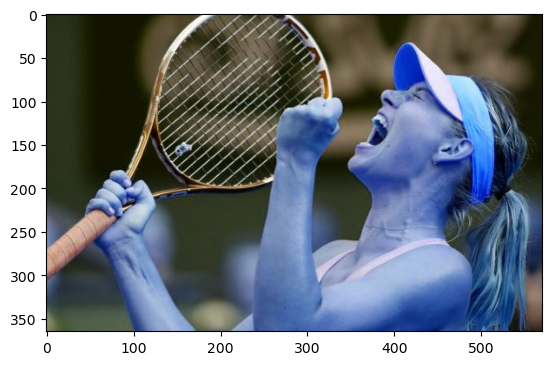

In [38]:
## LET'S CHECK HOW OUR FUNCTION BEHAVES FOR THE IMAGE WHICH DO NOT HAVE TWO EYES OR HALF FACE

original_image = cv2.imread('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/test_images/sharapova2.JPG')
plt.imshow(original_image)

# cropped_image_two = get_cropped_image_if_2_eyes('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/test_images/sharapova2.JPG')
# plt.imshow(cropped_image_two)


## WE CAN SEE AN ERROR IS RAISED SO THAT WE DONT WANT TO USE THE PARTICULAR IMAGE

# 
------------------------------------------------------

## *QUESTION : IN OUR DATASET WE HAVE TO CREATE A FOLDER CALLED CROPPED IN THAT WE HAVE TO STORE ALL THE CROPPED IMAGES* [DOING PROGRAMATICALLY]

In [43]:
## LET'S INITIALIZE SOME VARIABLES OR DEFINE SOME VARIABLES

path_to_dataset = '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset'
path_to_cr_data = '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/'

## ONE IS CURRENT WORKING DIRECTORY
## CR IS CROPPED --> WE ARE STORING ALL THE IMG IN CROPPED FOLDER

In [45]:
## IF THERE ARE MULTIPLE FOLDERS WE ARE IN NEED TO STORE ALL THE PATHS --> INTO ONE LIST
## HOW TO STORE ALL THE PATHS ????
## WE USE METHOS CALLED OS.SCANDIR --> IT BASICALLY GOES TO ALL SUB DIRECTORIES WITHIN THE ASSIGNED FOLDER [DATASET]


import os
img_dir_paths = []
for entry in os.scandir(path_to_dataset):
    if entry.is_dir():
        img_dir_paths.append(entry.path)

print(img_dir_paths)



['/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/maria_sharapova', '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/virat_kohli', '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/lionel_messi', '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/serena_williams', '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/roger_federer']


In [47]:
## NOW WE CAN CREATE FOLDERSBY USING THIS METHOD OR FUNCTION
## IF THE NEEDED FOLDER ALREADY EXISTS REMOVE THE FOLDER AND THEN INSERT NEW FOLDER
## IF EXISTIS --> REPLACE IF WE ARE NEED TO IMPROVE THE DATASET OR MADE CHANGES WE CAN REPLACE FOLDER
## HERE IT CREATES THE CROPPED FOLDER

import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

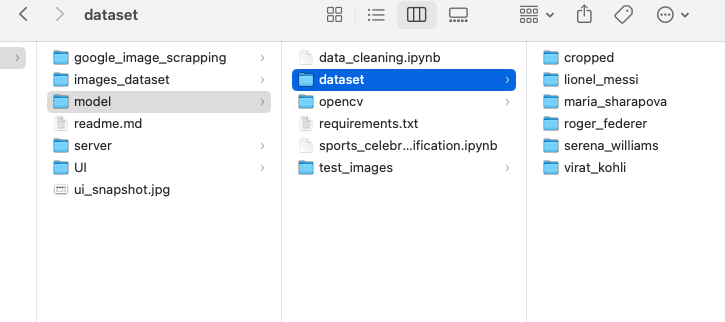

In [50]:
## NOW AS WE NEED TO INSERT DATA AS CROPPED IMAGES IN CROPPED FOLDER
## WE NEED TO ITERATE THROUGH ALL THE PATHS IN THE DATASET WITH IMAGES
## CROPPED_IMAGE_DIR_PATHS --> CONTAINS PATHS OF CROPPED IMAGES FOR EACH OF OUR FIVE PLAYERS
## as we know spllit() method and it does not include the splitting criteria
## HERE WE ARE USING SPLIT AND INDEXING TO GET OUTPUT AS PLAYER NAMES
## IF_ROI_COLOR IS NOT NONE WE NEED TO STORE THAT IMAGE INTO CROPPED FOLDER

cropped_image_dir_paths = []
celebrity_file_names_dict = {}

for img_dir in img_dir_paths:
    count = 1
    player_name = img_dir.split('/')[-1]

    # creating a blankdk array for each celeb name : blank array images path in dictionary 
    celebrity_file_names_dict[player_name] = []

    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            # AS WE HAVE BOTH PLAYES NAMES AND PATH_TO_CR_DATASET FOLDER = WE CAN CONCAT TOGETHER 
            cropped_folder = path_to_cr_data + player_name
            # AS WE HAVE TO CREATE EACH PLAYER SUB CROPPED FOLDER IN THE CROPPED FOLDER
            # EXAMPLE IF THE FOLDER DOESN'T EXIST USE OS.MKDIR TO CREATE CROPPED FOLDER
            if not os.path.exists(cropped_folder):
                os.mkdir(cropped_folder)
                cropped_image_dir_paths.append(cropped_folder)
                print('generating cropped images in folder: ' , cropped_folder)

            cropped_file_name = player_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            ## if we need to create names for each pic to get in sequence [ex: lionel_messi_1]

            ## MAINLY HOW TO SAVE ROI_COLOR AS IMAGE IN CROPPED_FILE_PATH
            cv2.imwrite(cropped_file_path,roi_color)

            ## IN THE SAME MANNER WE HAVE TO STORE ALL THE CROPPED_FILE PATHS INTO DICT
            celebrity_file_names_dict[player_name].append(cropped_file_path)
            count += 1



generating cropped images in folder:  /Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova
generating cropped images in folder:  /Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/virat_kohli
generating cropped images in folder:  /Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/lionel_messi
generating cropped images in folder:  /Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/serena_williams
generating cropped images in folder:  /Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/roger_federer


# *Creating dict of each image paths*
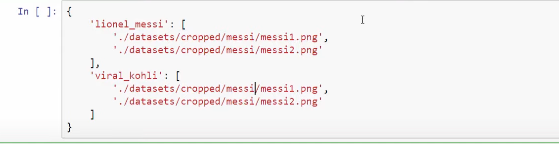

## *FEATURE ENGINEERING [SELECTING FEATURES X AND Y FOR MODEL BUILDING]*
   -  **WE USE WAVELET TRANSFORM**

In [54]:
import pywt
import numpy as np
import cv2

In [56]:
# FROM STACK OVERFLOW

def w2d(img,mode='harr',level = 1):
    imArray = img
    #DATATYPE CONVERSIONS 
    #CONVERT TO GRAYSCALE
    imArray = cv2.cvtColor(imArray,cv2.COLOR_RGB2GRAY)
    #CONVERT TO FLOAT
    imArray = np.float32(imArray)
    imArray /= 255
    #compute coefficients
    coeffs = pywt.wavedec2(imArray,mode,level=level)

    #process coefficients
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0;

    #RECONSTRUCTION
    imArray_H = pywt.waverec2(coeffs,mode)
    imArray_H  *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

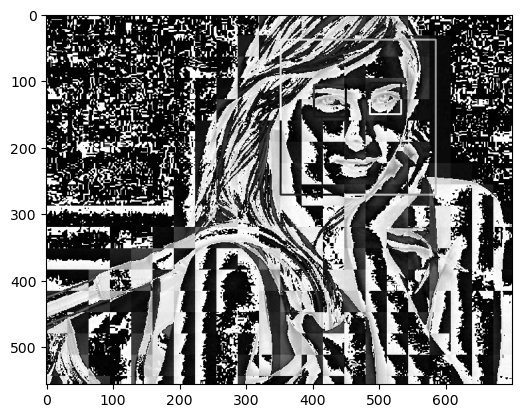

In [58]:
## NOW BY UNSING FUNCTION OF WAVELET TRANSFORM WE CAN SEE HOW IT GIVES OUTPUT
import warnings
im_harr = w2d(image_,'db1',5)
plt.imshow(im_harr, cmap = 'gray')

In [60]:
# NOW WE HAVE TO APPLY THIS WAVELET TRANSFORM METHOD FOR ALL THE IMAGES IN CROPPED FOLDER
# FOR THAT WE WILL DO --> VERTICAL STACKING OF IMAGES [RAW IMAGE +  VSTACK]

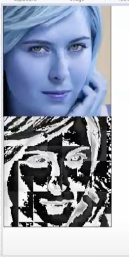

In [63]:
celebrity_file_names_dict

{'maria_sharapova': ['/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova1.png',
  '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova2.png',
  '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova3.png',
  '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova4.png',
  '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova5.png',
  '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova6.png',
  '/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova7.png',
  '/Users/punyashree/Documents/MY_FIRST_PRO

In [65]:
# WE HAVE TO ITERATE THROUGH THE DICTIONARY --> WITH ALL THE CROPPED IMAGES
# WE HAVE TO SCALE ALL THE IMAGES USING OPEN CV AS WHEN WE TRAIN ALL THE IMAGES SHOULD BE IN SAME SIZE
# EVEN THE WAVELET TRANSFORMED IMAGE MUST BE IN SAME DIMESIONS OF ORIGINAL --> AS WE VERTICALLY STACK
# NUMPY HAS THE FUNCTION TO VERTICALLY STACK THE IMAGES -> NP.VSTACK()
# AND OVERALL HERE WE NEED --> X AND Y
# X --> INPUT VARIABLE
# Y --> TARGET VARIABLE
# AS DIRECTLY WE CAN'T ASSIGN THE NAMES FIRSTLY WE HAVE TO GENERATE SOME INDEX VALUES TO EACH OF THE CELEBRITY NAMES

# TO ASSIGN THE INDEX VALUES OR NUMBER
# WE ITERATE THROUGH ALL THE INTEMS IN THE DICT AND ASSIGN NUMBER

class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1

class_dict


{'maria_sharapova': 0,
 'virat_kohli': 1,
 'lionel_messi': 2,
 'serena_williams': 3,
 'roger_federer': 4}

In [79]:
# WHERE THE DICT CAN BE USED TO RETURN NUMBER FOR CELEBRITY NAME
# NOW LET'S GENERATE X AND Y VALUES
import warnings
X,Y = [],[]
for celebrity_name,training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            print(f"warning: Failed to load image from {training_image}.Aswe have deleted some files manually.skipping")
            continue
        scaled_raw_img = cv2.resize(img,(32,32))
        img_harr = w2d(img,'db1',5)
        scaled_img_harr = cv2.resize(img_harr,(32,32))
        combined_img = np.vstack((scaled_raw_img.reshape(32*32*3,1),scaled_img_harr.reshape(32*32,1)))
        X.append(combined_img)
        Y.append(class_dict[celebrity_name])

[ WARN:0@5091.620] global loadsave.cpp:268 findDecoder imread_('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova1.png'): can't open/read file: check file path/integrity
[ WARN:0@5091.621] global loadsave.cpp:268 findDecoder imread_('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova2.png'): can't open/read file: check file path/integrity
[ WARN:0@5091.643] global loadsave.cpp:268 findDecoder imread_('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova5.png'): can't open/read file: check file path/integrity
[ WARN:0@5091.643] global loadsave.cpp:268 findDecoder imread_('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/maria_sharapova/maria_sharapova6.png'): can't open/read file: check file path/integrity
[ WARN:0@5091.649] globa

[ WARN:0@5091.838] global loadsave.cpp:268 findDecoder imread_('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/lionel_messi/lionel_messi20.png'): can't open/read file: check file path/integrity
[ WARN:0@5091.861] global loadsave.cpp:268 findDecoder imread_('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/serena_williams/serena_williams1.png'): can't open/read file: check file path/integrity
[ WARN:0@5091.861] global loadsave.cpp:268 findDecoder imread_('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/serena_williams/serena_williams2.png'): can't open/read file: check file path/integrity
[ WARN:0@5091.866] global loadsave.cpp:268 findDecoder imread_('/Users/punyashree/Documents/MY_FIRST_PROJECT/CelebrityFaceRecognition/model/dataset/cropped/serena_williams/serena_williams4.png'): can't open/read file: check file path/integrity
[ WARN:0@5091.870] global loa

In [83]:
len(X)

# IN TOTAL WE HAVE 73 CROPPED IMAGES

73

In [85]:
## LENGTH OF EACH IMAGE ==> LEN(X[0])
len(X[0])

4096

In [87]:
# how did we get 4096
32*32*3 + 32*32

4096

In [89]:
# NO BY USING NUMPY FUNCTION OF ASTYPE WE ARE CONVERTING THE ARRAY OF INPUT INTO FLOAT

X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(73, 4096)

In [91]:
# now each image arrays are in floating point number
X[0]

array([195., 195., 195., ..., 228., 198.,  12.])

## *WE CONVERT INTO FLOAT TO REDUCE SOME WARNINGS IN THE MODEL BUILDING PROCESS*

## **MODEL BUILDING**

In [99]:
# LET'S START WITH SVM 
# LET'S IMPORT THE NECESSALRY LIBRARIES AND MODELS
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [103]:
# AS WE HAVE ALREADY CLEANED THE DATA AND ASSIGNED X AND Y VARIABLES
# WE CAN EASILY NOW APPLY TRAIN TEST SPLIT ON BOTH X AND Y

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state = 0)

# WE HAVE TO CREATE A PIPELINE SO THAT WE CAN SCALE OR DATA USING STANDARD SCALER
pipe = Pipeline([('scaler',StandardScaler()),('svc',SVC(kernel = 'rbf' , C = 10))])
pipe.fit(X_train,Y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(C=10))])

In [105]:
pipe.score(X_test,Y_test)

0.2631578947368421

# *MODEL PREDICTION*

In [108]:
from sklearn.metrics import confusion_matrix

In [114]:
pred = pipe.predict(X_test)

In [116]:
pred[:5]

array([0, 0, 2, 4, 2])

In [120]:
Y_test[:5]

[3, 3, 1, 2, 1]

In [124]:
# CONFUSION MATRIX
print(confusion_matrix(Y_test,pred))

[[1 0 0 0 0]
 [2 0 2 0 0]
 [2 0 1 0 2]
 [3 0 0 0 0]
 [2 0 1 0 3]]


In [130]:
print(classification_report(Y_test,pred))

              precision    recall  f1-score   support

           0       0.10      1.00      0.18         1
           1       0.00      0.00      0.00         4
           2       0.25      0.20      0.22         5
           3       0.00      0.00      0.00         3
           4       0.60      0.50      0.55         6

    accuracy                           0.26        19
   macro avg       0.19      0.34      0.19        19
weighted avg       0.26      0.26      0.24        19



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [132]:
## UNTIL NOW WE HAVE CHECKED THE ACCURACY IN 'RBF' KERNEL
## WE CAN TRY USING ALL KERNELS TO CHECK ACCURACY SCORES

In [138]:
from sklearn.metrics import accuracy_score

list_of_kernels = ['linear','poly','rbf']
accuracy_scores = dict()

for k in list_of_kernels:
    model = SVC(kernel = k)
    model.fit(X_train,Y_train)
    Y_pred = model.predict(X_test)
    accuracy_scores[k] = accuracy_score(Y_test,Y_pred)

print(accuracy_scores)

{'linear': 0.3684210526315789, 'poly': 0.3157894736842105, 'rbf': 0.15789473684210525}


## *GRIDSEARCH CV()*
   - HELPS US TO HYPERTUNE THE PARAMETERS
   - **PERFORMS MODEL TRAINING ON ALL ALGORITHMS TOGETHER WE CAN SELECT THE BEST FIT MODEL**
   - **IMPORT ALL THE CLASSIFICATION ALGORITHMS AND MAKE A PIPELINE**

In [143]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [343]:
model_params = {
    'svm' : {
        'model' : svm.SVC(gamma = 'auto',probability = True),
        'params' : {
            'svc__C' : [0.001,0.01,0.1,1,10,100,1000],
            'svc__kernel' : ['rbf','linear']
        }
    },
    'random_forest' : {
        'model' : RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators' : [1,5,10]
        }
    },
    'logistic_regression' : {
        'model' :LogisticRegression(solver = 'liblinear',multi_class = 'auto'),
        'params' : {
            'logisticregression__C' : [1,5,10]
        }
    }
}

In [349]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf = GridSearchCV(pipe ,mp['params'],scoring = 'accuracy',verbose=1, n_jobs = -1, cv=5)
    clf.fit(X_train, Y_train)
    scores. append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators [algo] = clf.best_estimator_
    
df = pd.DataFrame(scores, columns=[ 'model', 'best_score', 'best_params '])
df

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits


,model,best_score,best_params
0,svm,0.427273,NaN
1,random_forest,0.409091,NaN
2,logistic_regression,0.296364,NaN


In [351]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc', SVC(C=10, gamma='auto', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, solver='liblinear'))])}

In [353]:
best_estimators['svm'].score(X_test,Y_test)

0.2631578947368421

In [355]:
best_estimators['random_forest'].score(X_test,Y_test)


0.3157894736842105

In [357]:
best_estimators['logistic_regression'].score(X_test,Y_test)


0.3684210526315789

In [359]:
best_clf = best_estimators['svm']

In [363]:
# let's check for confusion matrix of svm
confusion = confusion_matrix(Y_test,best_clf.predict(X_test))
confusion

array([[1, 0, 0, 0, 0],
       [2, 0, 2, 0, 0],
       [2, 0, 1, 0, 2],
       [3, 0, 0, 0, 0],
       [2, 0, 1, 0, 3]])

Text(95.72222222222221, 0.5, 'Truth')

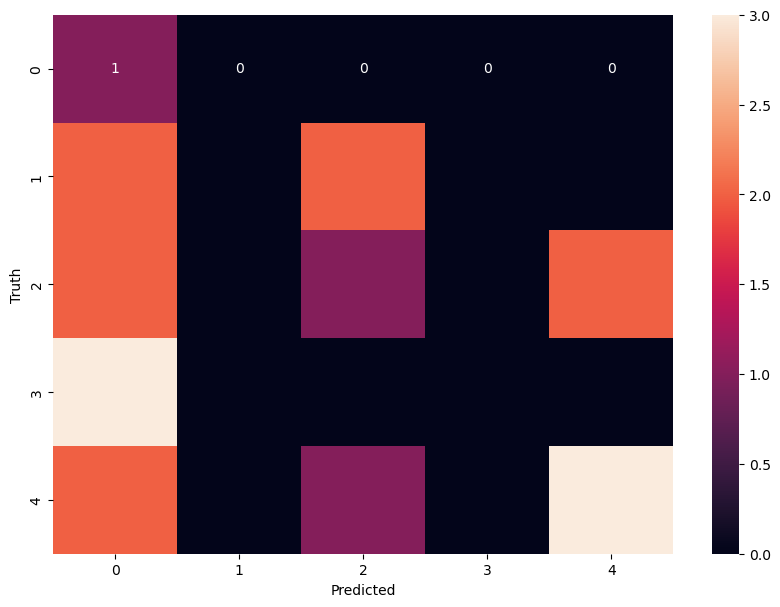

In [367]:
# IF WE STILL WANT TO SEE HOW MODEL HAS PERFORMED WE CAN USE HEATMAPS
import seaborn as sns
plt.figure(figsize = (10,7))
sns.heatmap(confusion, annot = True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

# *SAVING THE TRAINED MODEL*

In [370]:
# WE SAVE THE MODEL AS PICKLE IN THE FILE

import joblib
joblib.dump(best_clf,'first_saved_model_pk1')

['first_saved_model_pk1']